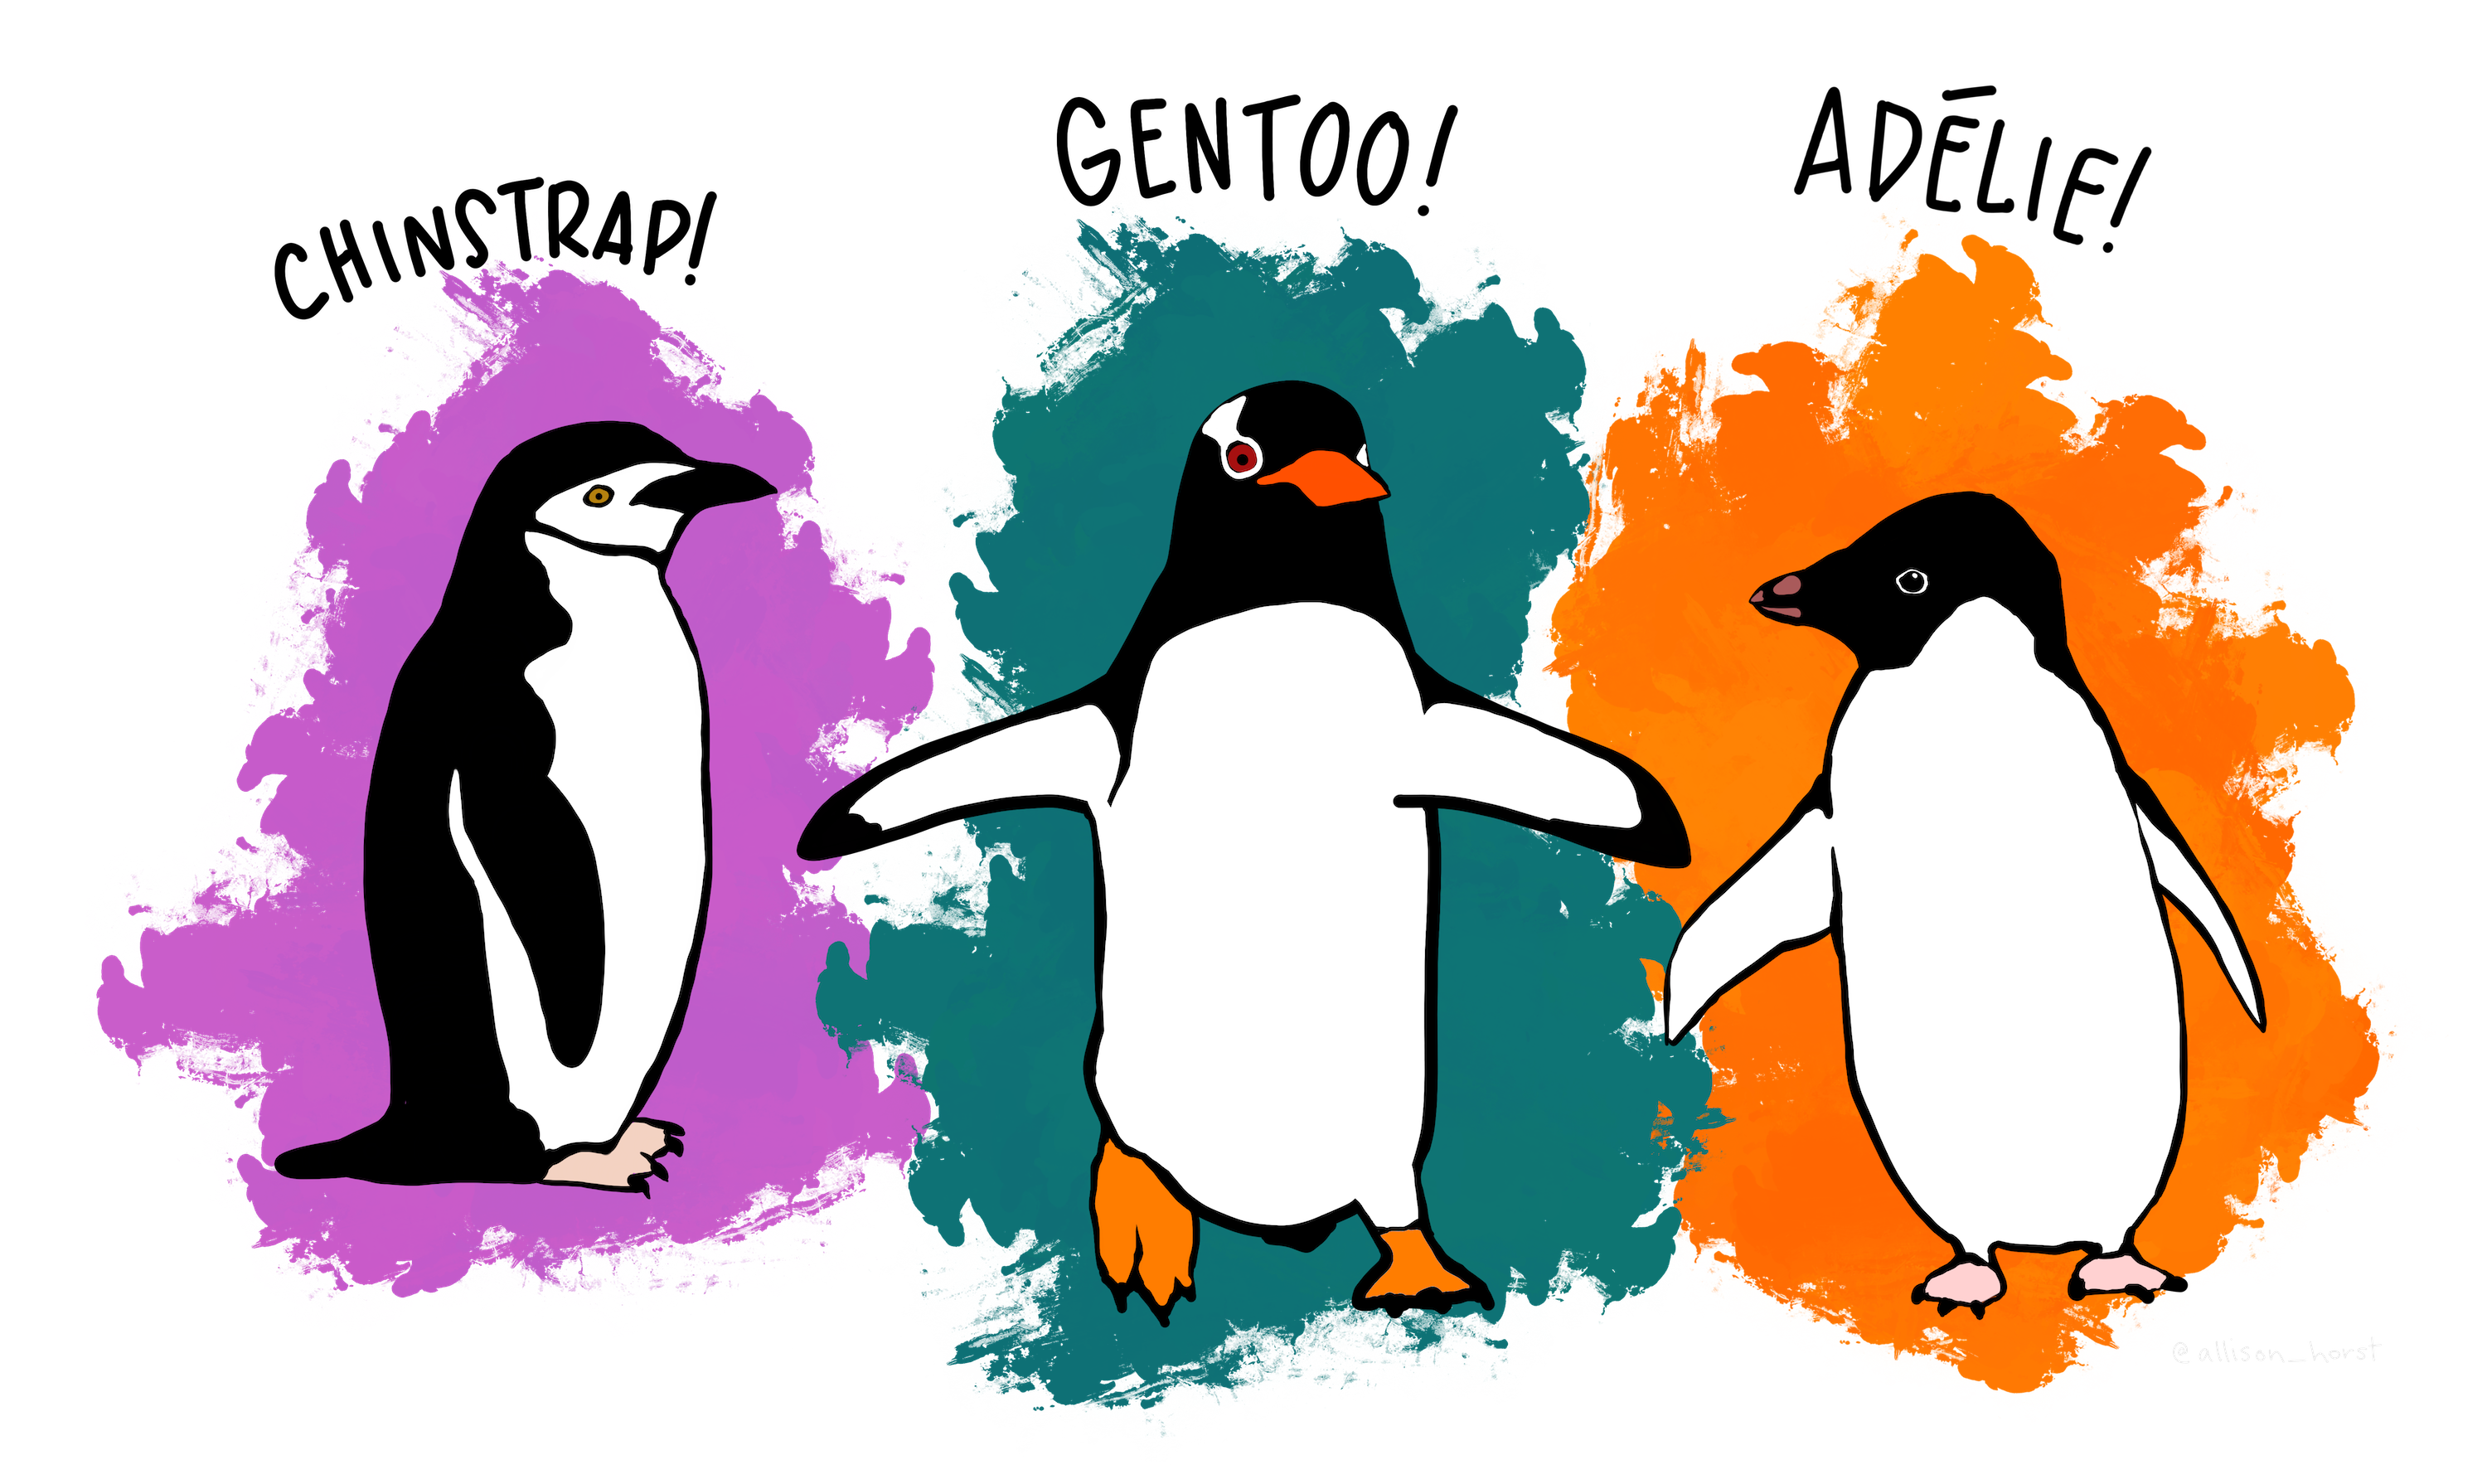

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

In [34]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [35]:
df=pd.read_csv("https://raw.githubusercontent.com/JohnMount/Penguins/main/penguins.csv")
df1=pd.read_csv("https://raw.githubusercontent.com/JohnMount/Penguins/main/penguins.csv")

In [36]:
df1.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female


In [37]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [38]:
df = df.dropna()

In [39]:
df.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


In [41]:
df=df.drop(columns=["species","island"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     333 non-null    float64
 1   bill_depth_mm      333 non-null    float64
 2   flipper_length_mm  333 non-null    float64
 3   body_mass_g        333 non-null    float64
 4   sex                333 non-null    object 
dtypes: float64(4), object(1)
memory usage: 15.6+ KB


In [42]:
df=df.drop('sex',axis=1).join(pd.get_dummies(df['sex'],drop_first=True).astype(int))
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     333 non-null    float64
 1   bill_depth_mm      333 non-null    float64
 2   flipper_length_mm  333 non-null    float64
 3   body_mass_g        333 non-null    float64
 4   male               333 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 15.6 KB


In [43]:
df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,male
0,39.1,18.7,181.0,3750.0,1
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
4,36.7,19.3,193.0,3450.0,0
5,39.3,20.6,190.0,3650.0,1


In [44]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
scaler= StandardScaler()
pca=PCA(n_components=2)
kmeans=KMeans(n_clusters=3,random_state=42)
pipe=make_pipeline(scaler,pca,kmeans)
pipe.fit(df)
df["cluster"] = pipe.predict(df)
df.groupby("cluster").mean()

d:\nihal\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,male
cluster,,,,,
0,41.551707,18.316585,191.312195,3687.317073,0.478049
1,49.840000,16.217143,219.514286,5337.500000,1.000000
2,45.563793,14.237931,212.706897,4679.741379,0.000000


Cluster analysis revealed three distinct groups. The cluster with the highest body mass and flipper length was identified as Gentoo, the smallest cluster with higher bill depth as Adelie, and the remaining cluster as Chinstrap.

Cluster 0 -> Adelie | 
Cluster 1 -> Gentoo | 
Cluster 2 -> Chinstrap

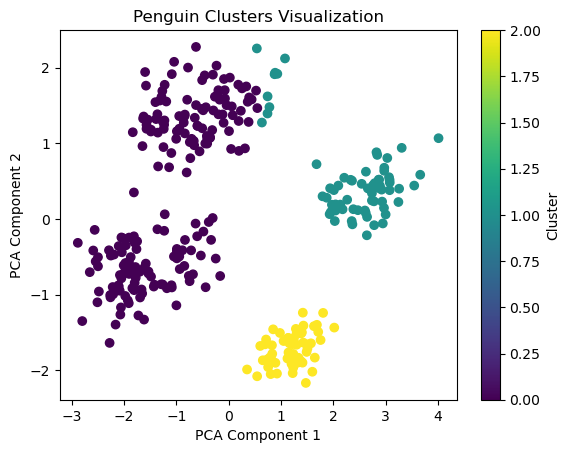

In [46]:
import matplotlib.pyplot as plt
X = df.drop(columns="cluster")


X_pca = pipe[0:2].transform(X)
plt.scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    c=df["cluster"], 
    cmap="viridis"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Penguin Clusters Visualization")

plt.colorbar(label="Cluster")
plt.show()

  	     	    
🟣 Purple	 , Cluster    0	     ,       Adelie |
🟢 Green/Teal	 ,Cluster 1	     ,       Gentoo |
🟡 Yellow	 , Cluster    2	  ,         Chinstrap
